<a href="https://colab.research.google.com/github/vish9571/Quantium_Sales/blob/data-cleaning/retail_ab_testing_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading data...

--- FINDING CONTROL STORES ---
Trial Store: 77  -->  Best Control Store: 233.0
Trial Store: 86  -->  Best Control Store: 155.0
Trial Store: 88  -->  Best Control Store: 178.0

--- GENERATING ASSESSMENT CHARTS ---

Evaluating Store 77...


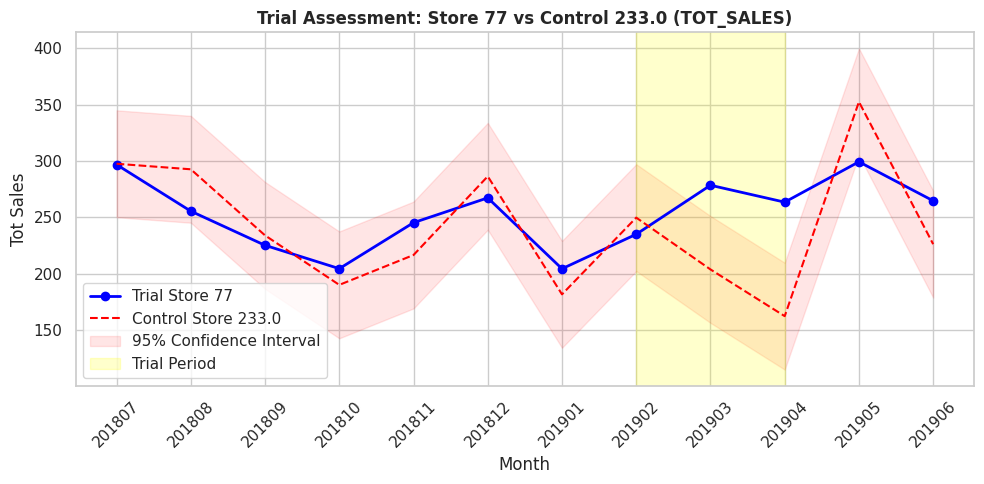

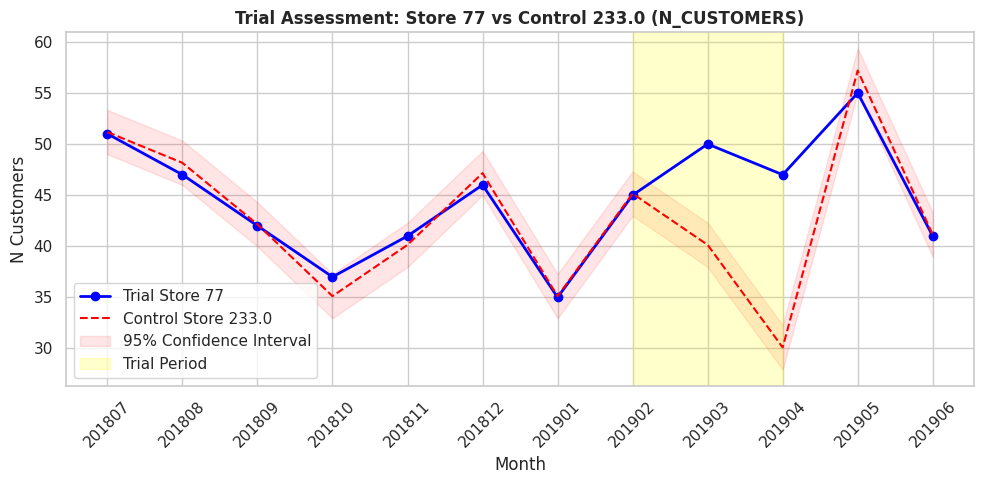


Evaluating Store 86...


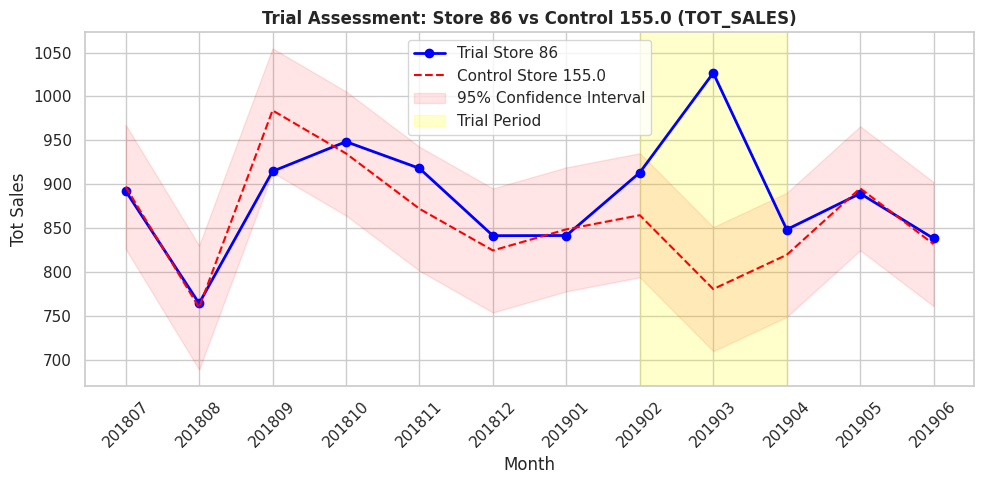

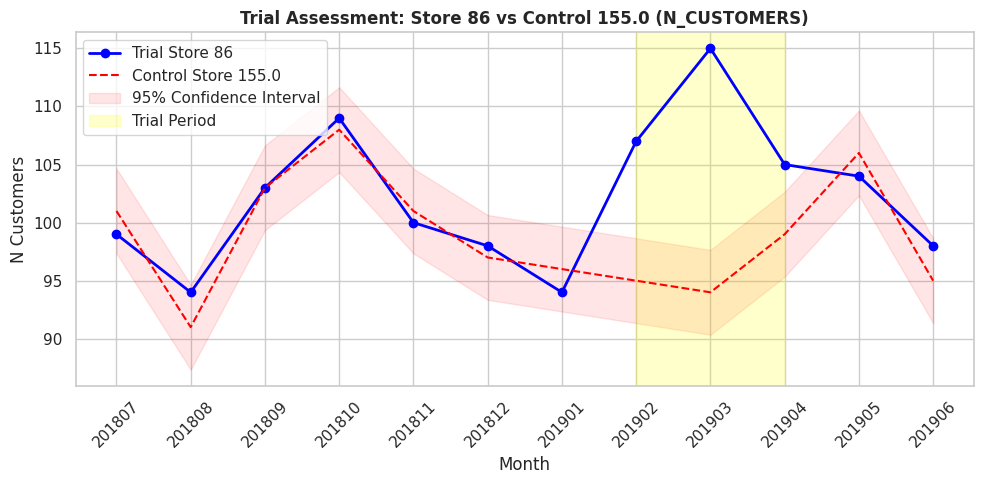


Evaluating Store 88...


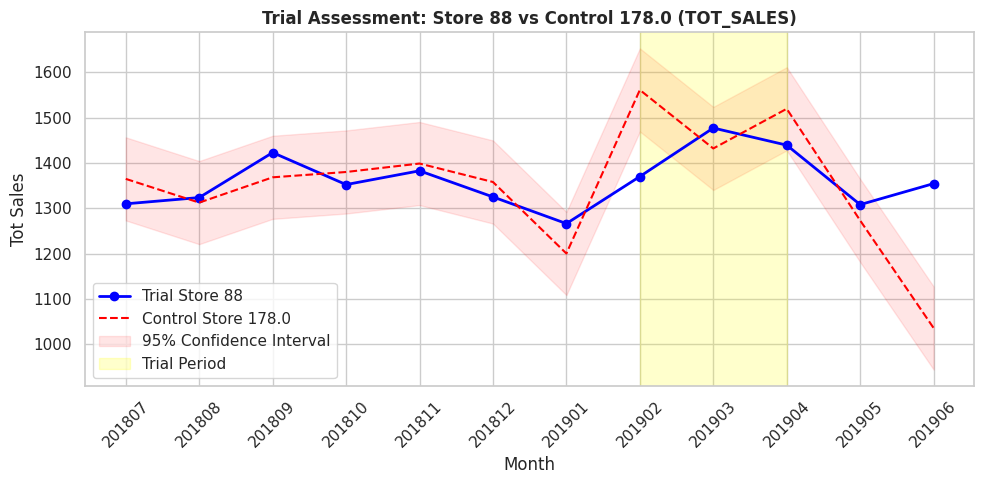

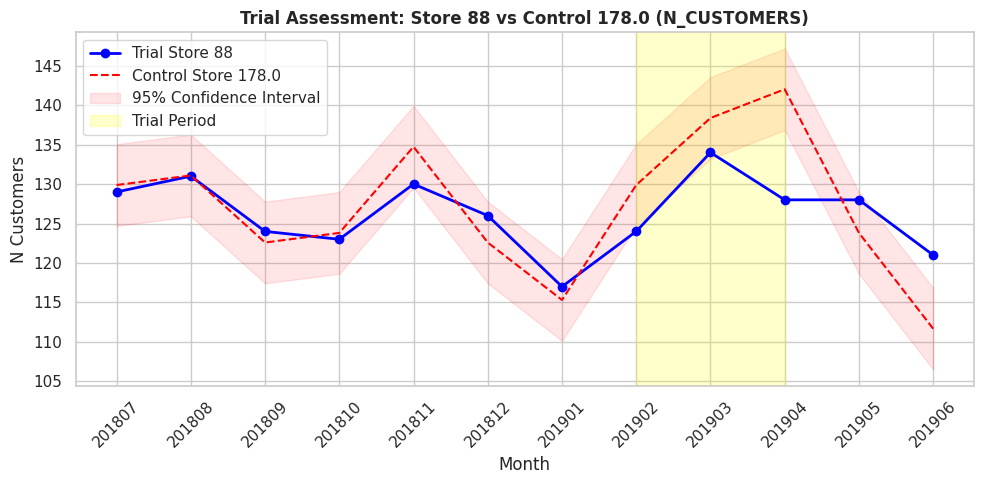

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


# load the data and set up our date formatting
print("Loading data...")
data = pd.read_csv('QVI_data.csv')
data['DATE'] = pd.to_datetime(data['DATE'])
data['YEARMONTH'] = data['DATE'].dt.strftime('%Y%m').astype(int)

# roll up the data to the monthly level for each store
monthly_metrics = data.groupby(['STORE_NBR', 'YEARMONTH']).agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'nunique'
}).reset_index()

monthly_metrics.rename(columns={'LYLTY_CARD_NBR': 'N_CUSTOMERS', 'TXN_ID': 'N_TXN'}, inplace=True)
monthly_metrics['TXN_PER_CUST'] = monthly_metrics['N_TXN'] / monthly_metrics['N_CUSTOMERS']

# we only want to look at stores that have a full year of data
store_counts = monthly_metrics['STORE_NBR'].value_counts()
full_stores = store_counts[store_counts == 12].index
metrics_full = monthly_metrics[monthly_metrics['STORE_NBR'].isin(full_stores)].copy()

# isolate the pre-trial period (july 2018 to jan 2019) for matching
pre_trial = metrics_full[metrics_full['YEARMONTH'] < 201902]


# helper function to calculate magnitude distance score (0 to 1)
def calculate_magnitude_distance(trial_series, control_series):
    diff = abs(trial_series.reset_index(drop=True) - control_series.reset_index(drop=True))
    min_diff = diff.min()
    max_diff = diff.max()

    # catch division by zero
    if max_diff == min_diff:
        return 1.0

    dist_score = 1 - ((diff - min_diff) / (max_diff - min_diff))
    return dist_score.mean()

# function to find the best control store based on sales and customer trends
def find_control_store(trial_store):
    trial_data = pre_trial[pre_trial['STORE_NBR'] == trial_store]

    scores = []
    for control_store in pre_trial['STORE_NBR'].unique():
        if control_store == trial_store:
            continue

        control_data = pre_trial[pre_trial['STORE_NBR'] == control_store]

        # calculate pearson correlations
        sales_corr, _ = pearsonr(trial_data['TOT_SALES'], control_data['TOT_SALES'])
        cust_corr, _ = pearsonr(trial_data['N_CUSTOMERS'], control_data['N_CUSTOMERS'])

        # calculate magnitude distances
        sales_mag = calculate_magnitude_distance(trial_data['TOT_SALES'], control_data['TOT_SALES'])
        cust_mag = calculate_magnitude_distance(trial_data['N_CUSTOMERS'], control_data['N_CUSTOMERS'])

        # blend the correlation and magnitude scores together equally
        corr_weight = 0.5
        score_sales = (sales_corr * corr_weight) + (sales_mag * (1 - corr_weight))
        score_cust = (cust_corr * corr_weight) + (cust_mag * (1 - corr_weight))
        final_score = (score_sales + score_cust) / 2

        scores.append({'Control_Store': control_store, 'Score': final_score})

    scores_df = pd.DataFrame(scores).sort_values(by='Score', ascending=False)
    return scores_df.iloc[0]['Control_Store']

print("\n--- FINDING CONTROL STORES ---")
trial_stores = [77, 86, 88]
control_pairs = {}

for ts in trial_stores:
    cs = find_control_store(ts)
    control_pairs[ts] = cs
    print(f"Trial Store: {ts}  -->  Best Control Store: {cs}")


# plot the trial performance vs the scaled control store
def assess_trial(trial_store, control_store, metric='TOT_SALES'):
    ts_data = metrics_full[metrics_full['STORE_NBR'] == trial_store].sort_values('YEARMONTH')
    cs_data = metrics_full[metrics_full['STORE_NBR'] == control_store].sort_values('YEARMONTH')

    # scale control store metrics to match trial store's pre-trial volume
    ts_pre_sum = ts_data[ts_data['YEARMONTH'] < 201902][metric].sum()
    cs_pre_sum = cs_data[cs_data['YEARMONTH'] < 201902][metric].sum()
    scaling_factor = ts_pre_sum / cs_pre_sum

    cs_data[f'Scaled_{metric}'] = cs_data[metric] * scaling_factor

    # calculate standard deviation of pre-trial diffs to get 95% confidence bounds
    pre_trial_diff = ts_data[ts_data['YEARMONTH'] < 201902][metric].values - cs_data[cs_data['YEARMONTH'] < 201902][f'Scaled_{metric}'].values
    std_dev = np.std(pre_trial_diff, ddof=1)

    cs_data['Threshold_95'] = cs_data[f'Scaled_{metric}'] + (std_dev * 2)
    cs_data['Threshold_5'] = cs_data[f'Scaled_{metric}'] - (std_dev * 2)

    months = ts_data['YEARMONTH'].astype(str).tolist()

    plt.figure(figsize=(10, 5))
    plt.plot(months, ts_data[metric], label=f'Trial Store {trial_store}', color='blue', marker='o', linewidth=2)
    plt.plot(months, cs_data[f'Scaled_{metric}'], label=f'Control Store {control_store}', color='red', linestyle='--')

    # shade the confidence interval area
    plt.fill_between(months, cs_data['Threshold_5'], cs_data['Threshold_95'], color='red', alpha=0.1, label='95% Confidence Interval')

    # highlight the actual trial months
    plt.axvspan('201902', '201904', color='yellow', alpha=0.2, label='Trial Period')

    plt.title(f'Trial Assessment: Store {trial_store} vs Control {control_store} ({metric})', fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\n--- GENERATING ASSESSMENT CHARTS ---")
# run the evaluation charts for sales and customers
for ts in trial_stores:
    print(f"\nEvaluating Store {ts}...")
    assess_trial(ts, control_pairs[ts], metric='TOT_SALES')
    assess_trial(ts, control_pairs[ts], metric='N_CUSTOMERS')